In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
def load_data(file_path):
    
	df = pd.read_csv(file_path, sep='\t')

	df.columns = df.columns.str.replace('[<>]', '', regex=True).str.capitalize()

	df.index = pd.to_datetime(df['Date'] + ' ' + df['Time'])
	df.index.name = 'Datetime'

	df.drop(columns=['Date', 'Time'], inplace=True)

	return df

In [20]:
def calculate_envelopes(series, period=20, deviation_percent=2):
	
	ma = series.ewm(span=period, adjust=False).mean()

	deviation = deviation_percent / 100.0
	
	upper = ma * (1 + deviation)
	lower = ma * (1 - deviation)
	
	return ma, upper, lower

In [21]:
def plot_envelopes(df, period, deviation_percent, start_date, end_date, 
                   title_name=None, xlim=None, ylim=None,xlabel='Datetime', ylabel='Price', max_labels=10):
    
	df_filtered = df.loc[start_date:end_date].copy()

	ma, upper, lower = calculate_envelopes(df_filtered['Close'], period, deviation_percent)

	df_filtered['plot_index'] = range(len(df_filtered))

	plt.figure(figsize=(12, 6))
	if title_name:
		plt.title(title_name)
	if xlim:
		plt.xlim(xlim)
	if ylim:
		plt.ylim(ylim)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.grid(True)
	plt.margins(x=0)

	plt.plot(df_filtered['plot_index'], upper, label='Upper', color='blue')
	plt.plot(df_filtered['plot_index'], df_filtered['Close'], label='Close', color='black')
	plt.plot(df_filtered['plot_index'], lower, label='Lower', color='red')

	ax = plt.gca()

	day_change = (df_filtered.index.date != pd.Series(df_filtered.index.date).shift(1).values)
	for idx in df_filtered[day_change]['plot_index'][1:]:
		ax.axvline(x=idx, color='gray', linestyle='--', linewidth=1, alpha=1)

	if len(df_filtered) > max_labels:
		step = len(df_filtered) // max_labels
		label_positions = df_filtered['plot_index'][::step]
		label_dates = df_filtered.index[::step]
	else:
		label_positions = df_filtered['plot_index']
		label_dates = df_filtered.index

	ax.set_xticks(label_positions)
	ax.set_xticklabels([d.strftime('%Y-%m-%d %H:%M') for d in label_dates], rotation=45, ha='right')

	plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
	plt.tight_layout()
	plt.show()

In [22]:
amd = load_data(r'data/AMD_M1_202510091630_202510132300.csv')
amd.head()

,Open,High,Low,Close,Tickvol,Vol,Spread
Datetime,,,,,,,
2025-10-09 16:30:00,236.21,237.45,235.27,237.36,4480,1429909,1
2025-10-09 16:31:00,237.36,239.10,236.75,239.05,2711,679696,1
2025-10-09 16:32:00,239.10,239.77,236.59,236.82,3597,878146,1
2025-10-09 16:33:00,236.86,237.71,234.50,234.80,3268,787399,1
2025-10-09 16:34:00,234.78,235.52,234.24,235.10,2200,495479,1


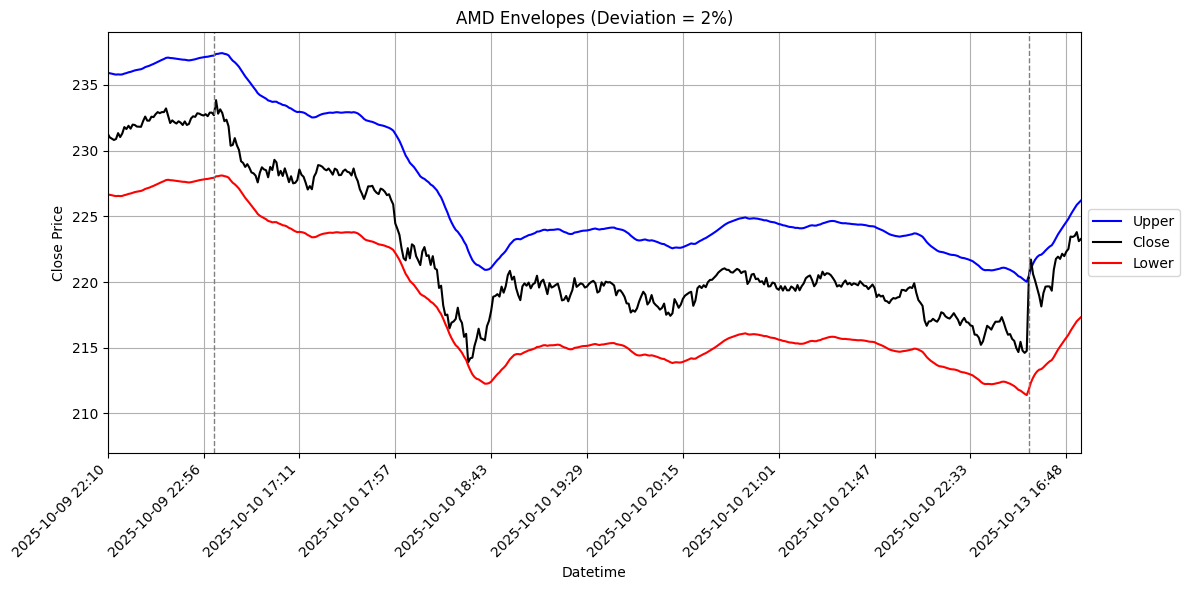

In [23]:
plot_envelopes(amd, 20, 2, '2025-10-09 22:10', '2025-10-13 16:55', 
               title_name='AMD Envelopes (Deviation = 2%)', xlim=None, ylim=(207, 239),
               xlabel='Datetime', ylabel='Close Price')

![](screenshots\AMDM1.png)

In [24]:
nvda = load_data(r'data/NVDA_M1_202510091630_202510132300.csv')
nvda.head()

,Open,High,Low,Close,Tickvol,Vol,Spread
Datetime,,,,,,,
2025-10-09 16:30:00,192.28,192.87,191.44,192.83,8570,4011286,1
2025-10-09 16:31:00,192.85,193.10,191.79,192.13,5349,1490549,1
2025-10-09 16:32:00,192.16,192.51,192.05,192.26,2470,650928,1
2025-10-09 16:33:00,192.26,192.30,191.62,191.92,2260,644538,1
2025-10-09 16:34:00,191.93,192.32,191.66,191.74,1799,578510,1


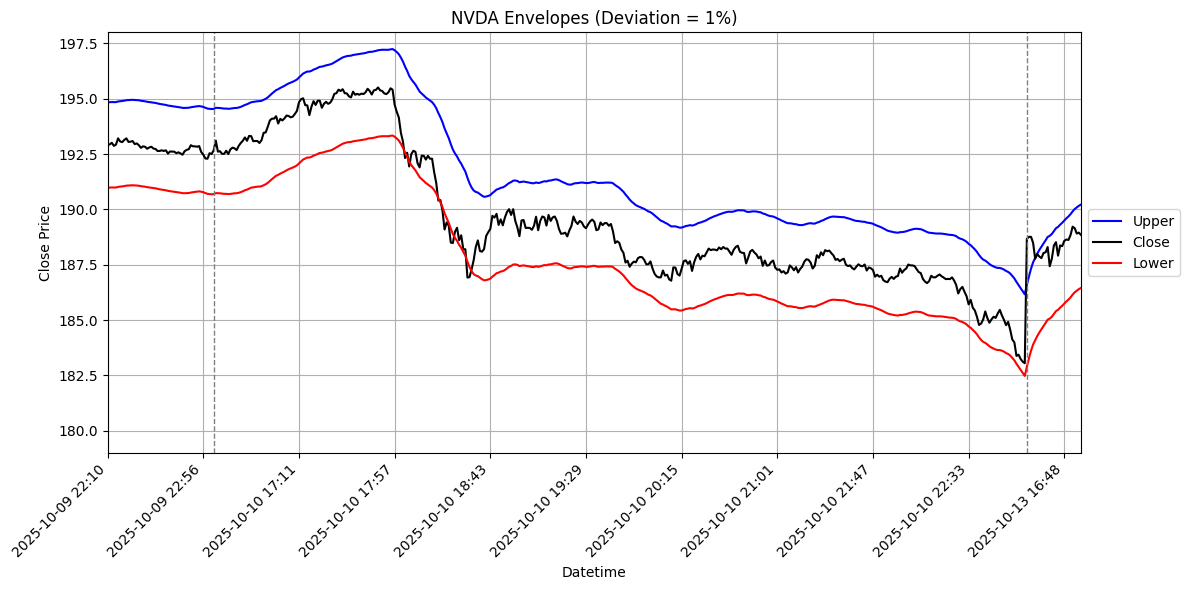

In [25]:
plot_envelopes(nvda, 20, 1, '2025-10-09 22:10', '2025-10-13 16:56', 
               title_name='NVDA Envelopes (Deviation = 1%)', xlim=None, ylim=(179, 198),
               xlabel='Datetime', ylabel='Close Price')

![](screenshots\NVDAM1.png)

In [26]:
def plot_oscillator(df, osc_series, start_date, end_date, 
										osc_name='Oscillator', title_name=None, 
                    xlim=None, ylim=None, xlabel='Date', ylabel='Price',
                    threshold_lines=None, colors=('black', 'red'), max_labels=10):

	df_filtered = df.loc[start_date:end_date].copy()
	osc_series = osc_series.loc[start_date:end_date].copy()

	first_valid = osc_series.first_valid_index()
	if first_valid is not None:
		df_plot = df_filtered.loc[first_valid:].copy()
		osc_plot = osc_series.loc[first_valid:].copy()
	else:
		df_plot = df_filtered.copy()
		osc_plot = osc_series.copy()

	df_plot['plot_index'] = range(len(df_plot))

	fig, (ax_price, ax_osc) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, 
	                                        gridspec_kw={'height_ratios': [2, 1]})

	ax_price.plot(df_plot['plot_index'], df_plot['Close'], color=colors[0], label=ylabel)
	ax_price.set_ylabel(ylabel)
	ax_price.legend(loc='upper left', bbox_to_anchor=(1, 1))
	ax_price.grid(True)

	ax_osc.plot(df_plot['plot_index'], osc_plot, color=colors[1], label=osc_name)
	ax_osc.set_ylabel(osc_name)
	ax_osc.set_xlabel(xlabel)
	ax_osc.legend(loc='upper left', bbox_to_anchor=(1, 1))
	ax_osc.grid(True)

	if threshold_lines:
		for line in threshold_lines:
			ax_osc.axhline(line, color='gray', linestyle='--', alpha=1)

	day_change = df_plot.index.date != pd.Series(df_plot.index.date).shift(1).values
	for idx in df_plot[day_change]['plot_index'][1:]:
		ax_price.axvline(x=idx, color='gray', linestyle='--', linewidth=1, alpha=1)
		ax_osc.axvline(x=idx, color='gray', linestyle='--', linewidth=1, alpha=1)

	if len(df_plot) > max_labels:
		step = len(df_plot) // max_labels
		label_positions = df_plot['plot_index'][::step]
		label_dates = df_plot.index[::step]
	else:
		label_positions = df_plot['plot_index']
		label_dates = df_plot.index

	ax_osc.set_xticks(label_positions)
	ax_osc.set_xticklabels([d.strftime('%Y-%m-%d %H:%M') for d in label_dates], rotation=45, ha='right')

	if xlim:
		ax_price.set_xlim(xlim)
	if ylim:
		ax_price.set_ylim(ylim)

	ax_price.margins(x=0)
	ax_osc.margins(x=0)

	if title_name:
		fig.suptitle(title_name, fontsize=16)

	plt.tight_layout()
	plt.show()

In [27]:
def calculate_demarker(high, low, period=14):
	
	demax = (high - high.shift(1)).clip(lower=0)
	demin = (low.shift(1) - low).clip(lower=0)

	demax_sma = demax.rolling(window=period).mean()
	demin_sma = demin.rolling(window=period).mean()

	demarker = demax_sma / (demax_sma + demin_sma)

	return demarker

In [28]:
appl = load_data(r'data/AAPL_M1_202510091630_202510132300.csv')
appl.head()

,Open,High,Low,Close,Tickvol,Vol,Spread
Datetime,,,,,,,
2025-10-09 16:30:00,257.90,258.00,257.03,257.07,1950,701806,1
2025-10-09 16:31:00,257.02,257.53,257.00,257.08,696,95960,1
2025-10-09 16:32:00,257.10,257.12,256.66,256.84,694,130219,1
2025-10-09 16:33:00,256.83,257.07,256.47,256.79,571,119211,1
2025-10-09 16:34:00,256.79,256.81,256.33,256.57,443,64459,1


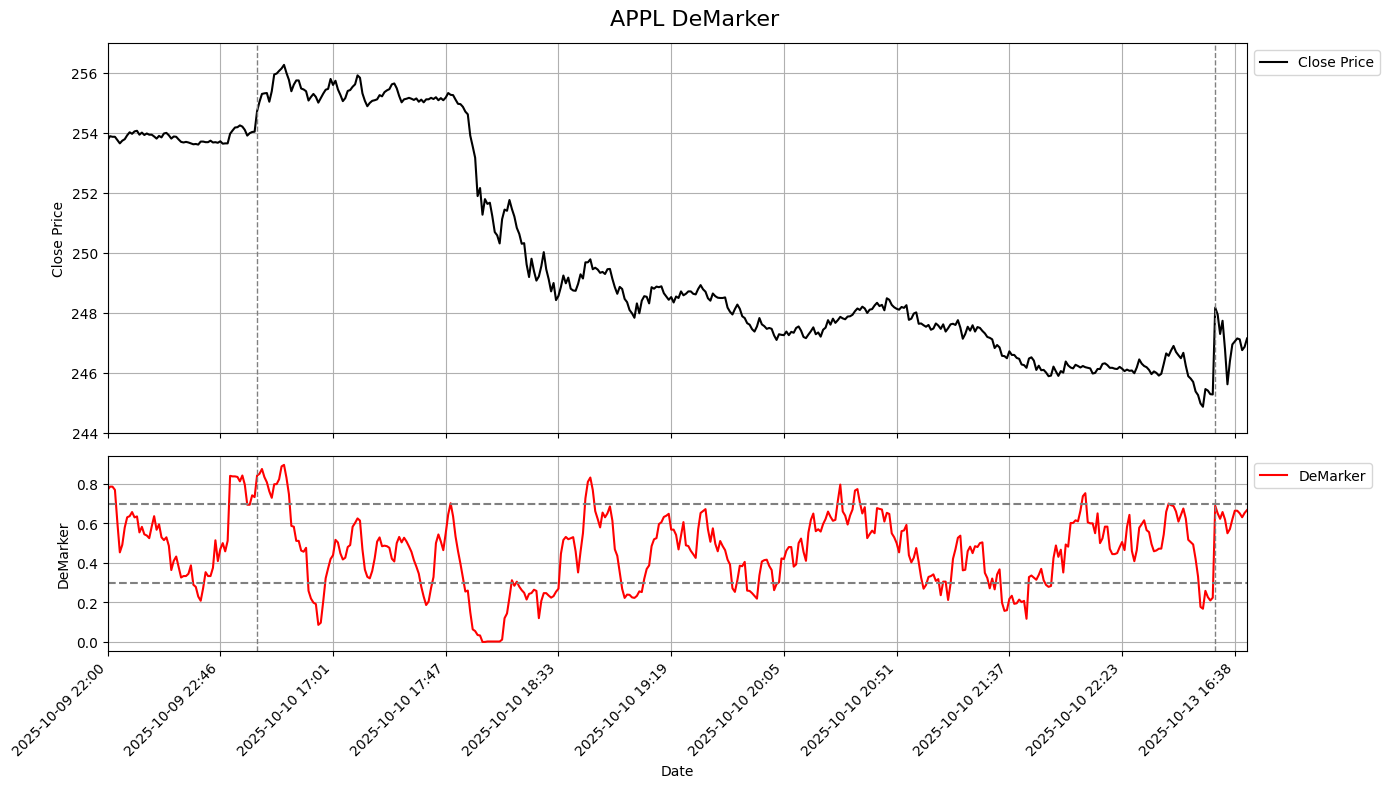

In [29]:
demarker = calculate_demarker(appl['High'], appl['Low'], period=14)
plot_oscillator(appl, demarker, '2025-10-09 22:00', '2025-10-13 16:43', 
                osc_name='DeMarker', title_name='APPL DeMarker', 
                xlim=None, ylim=(244, 257), xlabel='Date', ylabel='Close Price',
                    threshold_lines=(0.3, 0.7))

![Alt text](screenshots/AAPLM1.png)

In [30]:
msft = load_data(r'data/MSFT_M1_202510091630_202510132300.csv')
msft.head()

,Open,High,Low,Close,Tickvol,Vol,Spread
Datetime,,,,,,,
2025-10-09 16:30:00,522.34,523.93,521.80,522.89,1084,325138,1
2025-10-09 16:31:00,522.90,524.33,522.72,523.51,126,23651,1
2025-10-09 16:32:00,523.50,523.61,523.04,523.21,99,14898,1
2025-10-09 16:33:00,523.13,523.89,523.00,523.70,98,17734,1
2025-10-09 16:34:00,523.82,524.11,522.83,522.94,96,15249,1


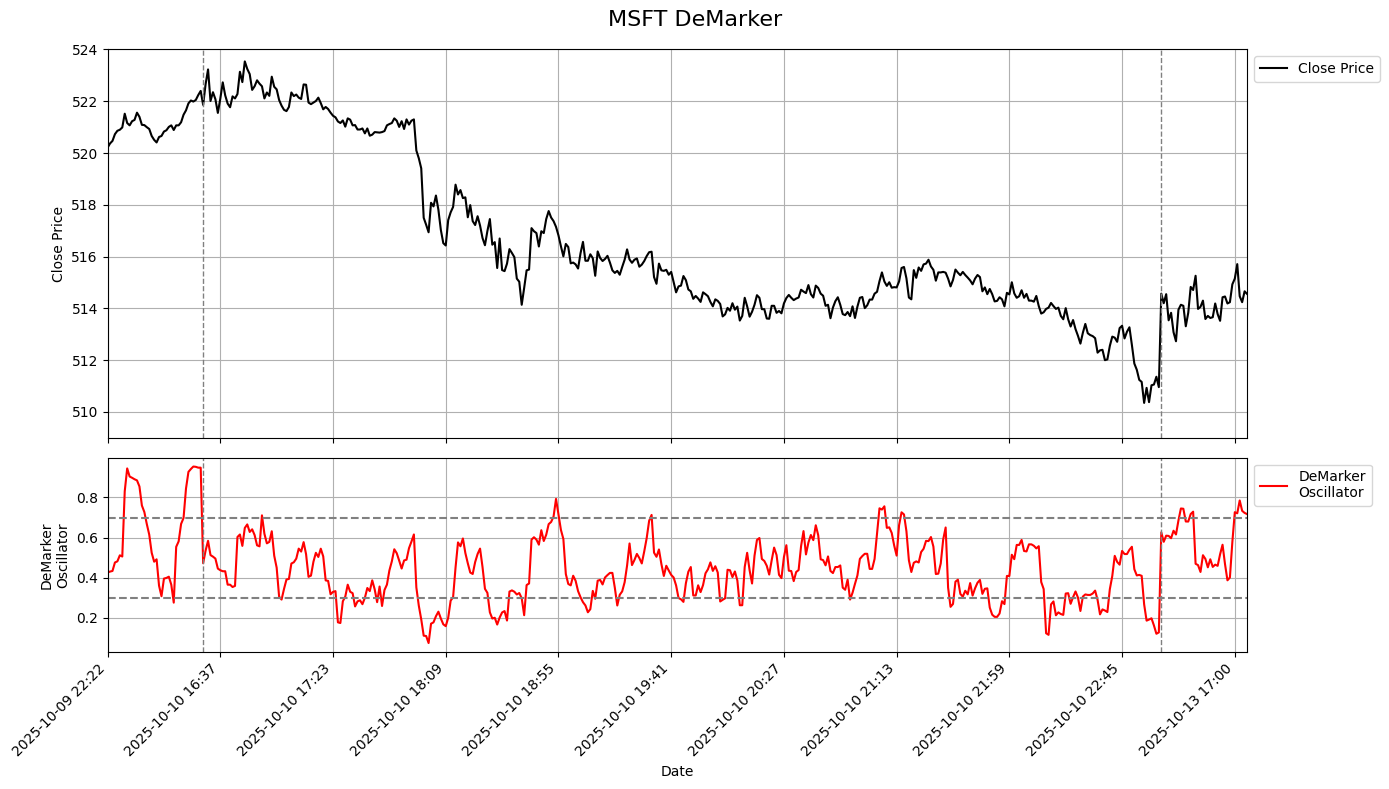

In [31]:
demarker = calculate_demarker(msft['High'], msft['Low'], period=14)
plot_oscillator(msft, demarker, 
                    start_date='2025-10-09 22:22', end_date='2025-10-13 17:05',
                    osc_name='DeMarker\nOscillator', title_name='MSFT DeMarker',
                    xlim=None, ylim=(509, 524), xlabel='Date', ylabel='Close Price',
                    threshold_lines=[0.3, 0.7])

![Alt text](screenshots/MSFTM1.png)

In [32]:
def calculate_chaikin(df, short_period=3, long_period=10):

	money_flow_multiplier = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'])
	money_flow_multiplier = money_flow_multiplier.fillna(0)

	money_flow_volume = money_flow_multiplier * df['Tickvol']

	adl = money_flow_volume.cumsum()

	adl_ema_short = adl.ewm(span=short_period, adjust=False).mean()
	adl_ema_long = adl.ewm(span=long_period, adjust=False).mean()

	chaikin_osc = adl_ema_short - adl_ema_long

	return chaikin_osc

In [33]:
amzn = load_data(r'data/AMZN_M1_202510091630_202510132300.csv')
amzn.head()

,Open,High,Low,Close,Tickvol,Vol,Spread
Datetime,,,,,,,
2025-10-09 16:30:00,224.92,225.12,223.86,224.64,2036,622343,1
2025-10-09 16:31:00,224.67,224.95,223.68,223.72,878,135990,1
2025-10-09 16:32:00,223.70,223.89,223.45,223.62,781,135550,1
2025-10-09 16:33:00,223.63,223.94,223.58,223.81,755,177533,1
2025-10-09 16:34:00,223.82,224.14,223.58,223.94,592,119748,1


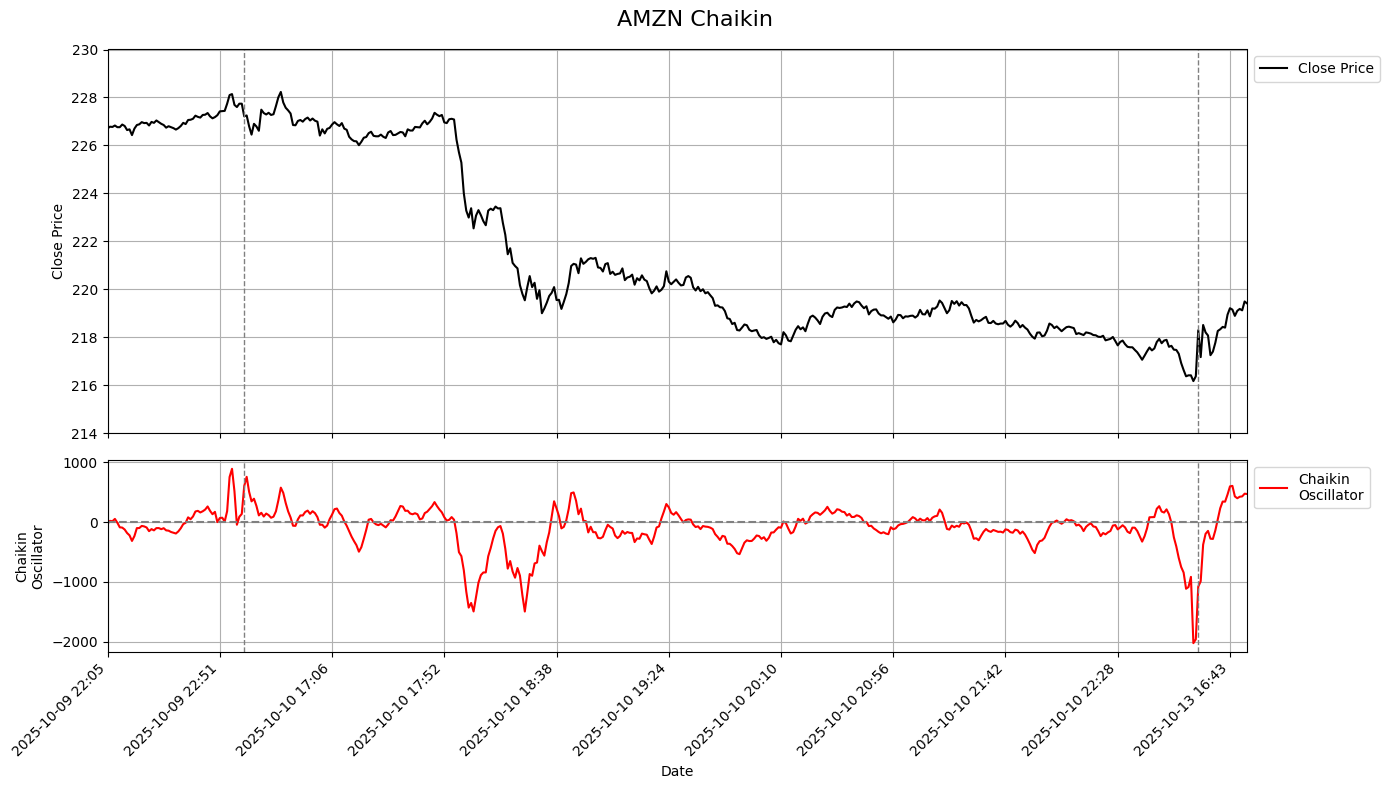

In [34]:
chaikin = calculate_chaikin(amzn, short_period=3, long_period=10)
plot_oscillator(amzn, chaikin, 
                    start_date='2025-10-09 22:05', end_date='2025-10-13 16:50', 
                    osc_name='Chaikin\nOscillator', title_name='AMZN Chaikin',
                    xlim=None, ylim=(214, 230), xlabel='Date', ylabel='Close Price',
                    threshold_lines=[0], colors=('black', 'red'))

![Alt text](screenshots/AMZNM1.png)

In [35]:
meta = load_data(r'data/META_M1_202510091630_202510132300.csv')
meta.head()

,Open,High,Low,Close,Tickvol,Vol,Spread
Datetime,,,,,,,
2025-10-09 16:30:00,718.27,719.68,716.87,717.84,407,155133,1
2025-10-09 16:31:00,717.95,719.71,717.85,719.03,90,18421,2
2025-10-09 16:32:00,719.12,719.74,717.87,718.84,80,13768,1
2025-10-09 16:33:00,718.95,720.46,718.83,720.13,143,24046,1
2025-10-09 16:34:00,720.08,721.31,719.70,720.74,154,23483,1


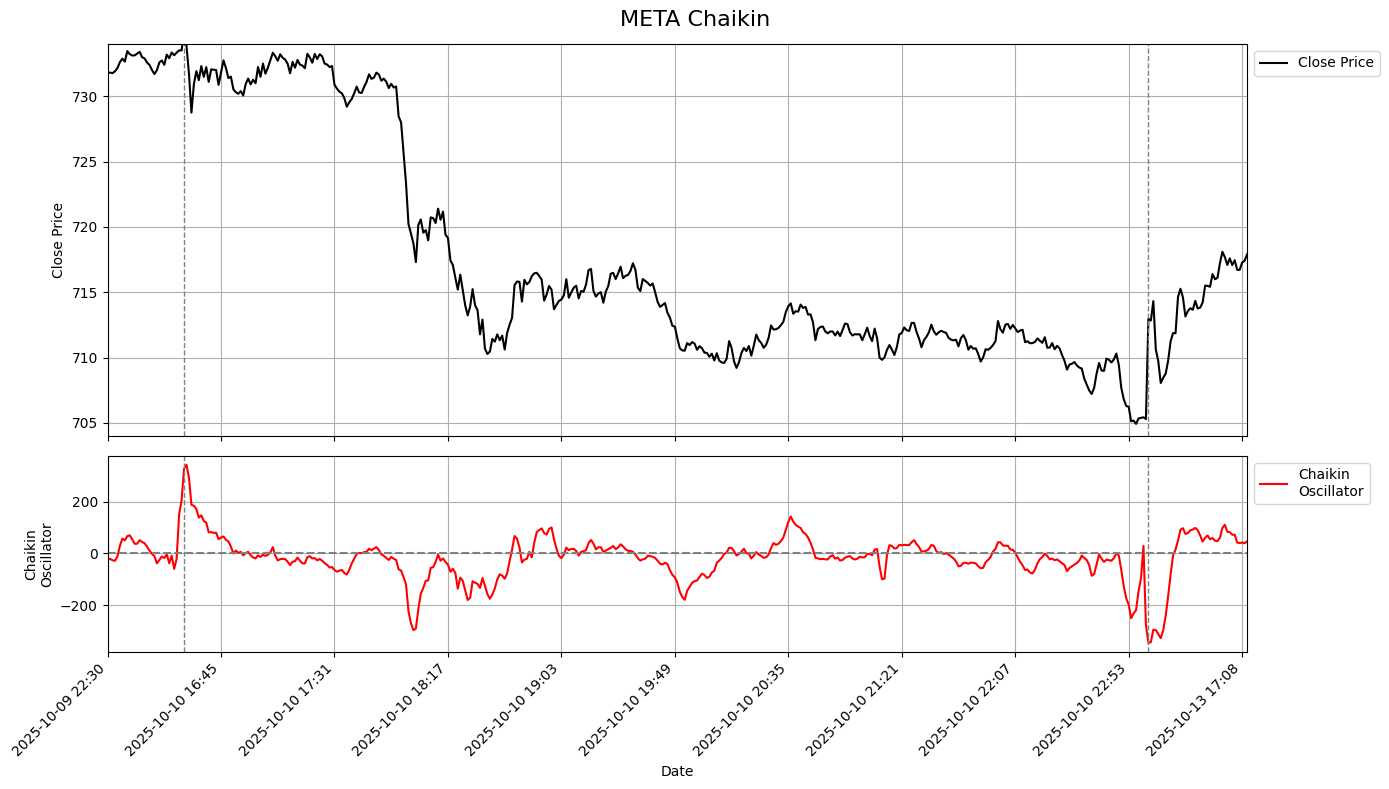

In [36]:
chaikin = calculate_chaikin(meta, short_period=3, long_period=10)
plot_oscillator(meta, chaikin, 
                    start_date='2025-10-09 22:30', end_date='2025-10-13 17:10', 
                    osc_name='Chaikin\nOscillator', title_name='META Chaikin',
                    xlim=None, ylim=(704, 734), xlabel='Date', ylabel='Close Price',
                    threshold_lines=[0], colors=('black', 'red'))

![Alt text](screenshots/METAM1.png)